In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Load data
insurance_data = pd.read_csv("insurance.csv")

In [4]:
insurance_data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


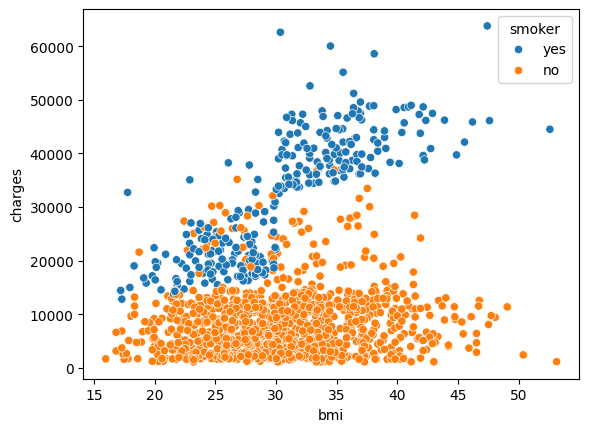

In [5]:
# visualize
sns.scatterplot(x=insurance_data["bmi"], y=insurance_data["charges"], hue=insurance_data["smoker"])
plt.show()

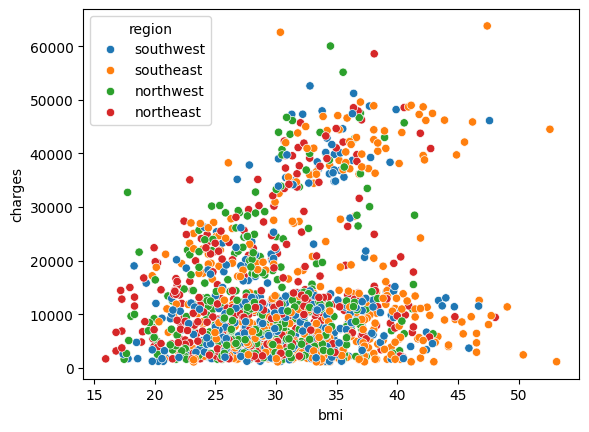

In [6]:
# visualize
sns.scatterplot(x=insurance_data["bmi"], y=insurance_data["charges"], hue=insurance_data["region"])
plt.show()

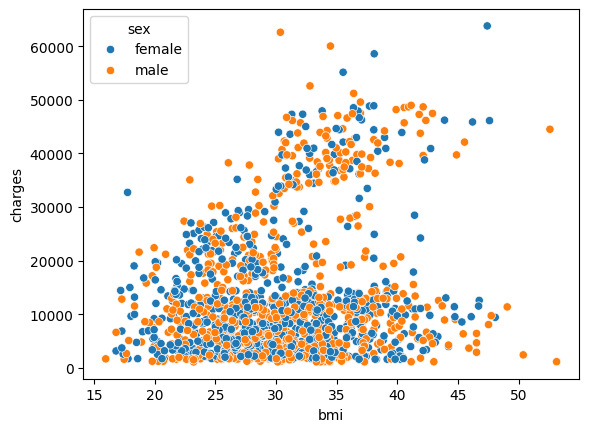

In [7]:
# visualize
sns.scatterplot(x=insurance_data["bmi"], y=insurance_data["charges"], hue=insurance_data["sex"])
plt.show()

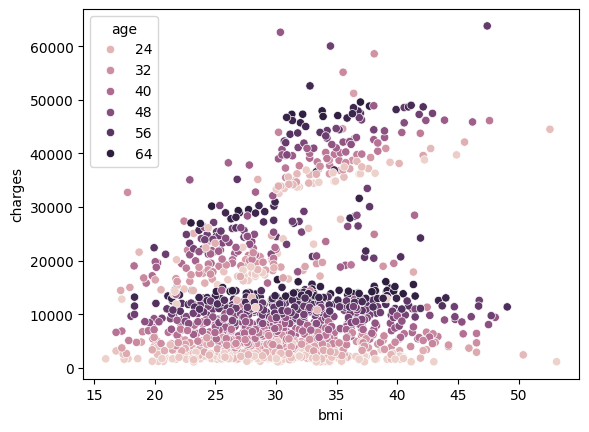

In [8]:
# visualize
sns.scatterplot(x=insurance_data["bmi"], y=insurance_data["charges"], hue=insurance_data["age"])
plt.show()

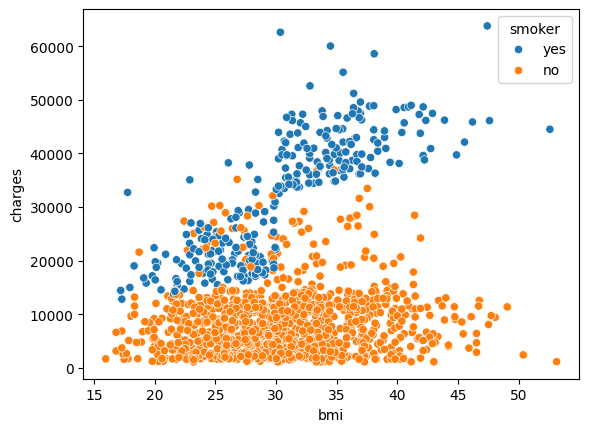

In [9]:
# visualize
sns.scatterplot(x=insurance_data["bmi"], y=insurance_data["charges"], hue=insurance_data["smoker"])
plt.show()

In [10]:
X = insurance_data.drop(columns=["charges", "region"])
y = insurance_data["charges"]

X["sex"] =X["sex"].map({"female": 0, "male": 1})
X["smoker"] =X["smoker"].map({"no": 0, "yes": 1})

In [11]:
X.head()

,age,sex,bmi,children,smoker
0,19,0,27.900,0,1
1,18,1,33.770,1,0
2,28,1,33.000,3,0
3,33,1,22.705,0,0
4,32,1,28.880,0,0


In [12]:
# Train Test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [13]:
X_test.head()

,age,sex,bmi,children,smoker
764,45,0,25.175,2,0
887,36,0,30.020,0,0
890,64,0,26.885,0,1
1293,46,1,25.745,3,0
259,19,1,31.920,0,1


In [14]:
# Train model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
# Predict values
y_pred = model.predict(X_test)

In [16]:
y_pred

array([ 8554.81711589,  6973.58746745, 36798.60416104,  9417.88282303,
       26871.68031081, 11097.38383938,   145.27608963, 16746.1683771 ,
         747.53414191, 11153.67590722, 28518.15016561,  9292.18345421,
        5460.51975119, 38510.48013003, 40359.30938604, 37223.40538064,
       15316.56711945, 36047.50032223,  9326.29049907, 31400.1559532 ,
        4269.64414373, 10464.66374097,  2719.9260555 ,  6579.53742551,
       11232.00255515, 12472.06793446, 14807.11281089,  6066.19283362,
        9535.69029723,  2377.6983797 ,  9475.05690885, 12963.23366722,
        4706.09057393,  3414.674504  ,  4815.64981654, 12484.17176954,
        2359.13614479,  9161.02061228, 33238.67621442, 32743.41702445,
        4274.58967205,  4229.5442107 , 14435.36485176, 11384.66898976,
        8925.70468583, 12480.09178788,  5154.45787816,  3554.10047649,
       35649.60942684,  9276.25523701, 15971.35991397,  2552.75200479,
       12162.99980138,  1062.65132285, 13551.43771934, 12103.65505529,
      

In [17]:
y_test

764      9095.06825
887      5272.17580
890     29330.98315
1293     9301.89355
259     33750.29180
           ...     
109     47055.53210
575     12222.89830
535      6067.12675
543     63770.42801
846      9872.70100
Name: charges, Length: 268, dtype: float64

In [18]:
# Evaluate
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("r-squared:", r2)

n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2 = 1 -((1-r2) * (n-1) / (n-p-1))
print("adjusted r^2:", adjusted_r2)

r-squared: 0.7811302113434095
adjusted r^2: 0.7769533069797342


In [19]:
X_test.shape

(268, 5)

### Feature Engineering

In [20]:
# One Hot Encoding

X = insurance_data.drop(columns=["charges"])
y = insurance_data["charges"]

X = pd.get_dummies(X, columns=["region"], drop_first=True, dtype=int)

X["sex"] = X["sex"].map({"female":1, "male": 0})
X["smoker"] = X["smoker"].map({"yes":1, "no": 0})

In [21]:
X.sample(10)

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
971,34,1,23.560,0,0,0,0,0
304,57,1,38.000,2,0,0,0,1
289,52,0,26.400,3,0,0,1,0
158,30,0,35.530,0,1,0,1,0
1168,32,0,35.200,2,0,0,0,1
48,60,1,24.530,0,0,0,1,0
556,46,0,33.440,1,0,0,0,0
553,52,1,31.730,2,0,1,0,0
904,60,1,35.100,0,0,0,0,1
1067,39,0,42.655,0,0,0,0,0


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
print("r2 score: ", r2)

r2 score:  0.7835929767120723


In [23]:
# Intrection Features
X = insurance_data.drop(columns=["charges"])
y = insurance_data["charges"]

X = pd.get_dummies(X, columns=["region"], drop_first=True, dtype=int)

X["sex"] = X["sex"].map({"female":1, "male": 0})
X["smoker"] = X["smoker"].map({"yes":1, "no": 0})

X["age_smoker"] = X["age"] * X["smoker"]
X["bmi_smoker"] = X["bmi"] * X["smoker"]

In [24]:
X.head()

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest,age_smoker,bmi_smoker
0,19,1,27.900,0,1,0,0,1,19,27.9
1,18,0,33.770,1,0,0,1,0,0,0.0
2,28,0,33.000,3,0,0,1,0,0,0.0
3,33,0,22.705,0,0,1,0,0,0,0.0
4,32,0,28.880,0,0,1,0,0,0,0.0


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
print("r2 score: ", r2)

r2 score:  0.865231697953168


In [26]:
# underfit & overfit
# r2 training is low & r2 testing is also low - underfit
# r2 training >> r2 testing is also low - overfit

y_train_pred = model.predict(X_train)
r2_train = r2_score(y_train, y_train_pred)

print("Training data r2:", r2_train)
print("Test data r2:", r2)

Training data r2: 0.8340713711218875
Test data r2: 0.865231697953168
